# OutdoorKoi — Forecast × Reality Exploration Pipeline

**Periods-only** (`twenty_four_hr_periods.csv`, 5 regions × 4 blocks) + `four_day_outlook.csv`, joined to
**observed** Woodlands-cluster rainfall and observed air temperature.

| § | What it does |
|---|---|
| 0 | Config, schema mapping, loaders (edit §0 only) |
| 1 | Build the two analysis tables: **block-level transactions** (date × 6h block) and **daily table** |
| 2 | **Apriori** (mlxtend): mine on train years, re-score every rule on held-out years, flag genuine interactions |
| 3 | **Forecast × reality damage table** — physics-derived impact per outcome, with provenance |
| 4 | **Two-channel "normal day" axes** — heat and wet kept separate; mean/median/SD per forecast tier |
| 5 | **Intervention bins** — `PREEMPT` / `WINDOW` / `REACT` / `NONE`, validated per year and on held-out data |
| 6 | **Simple ML** — does the outlook add skill over the thermometer alone? (+1/+3/+5 d), rain target as control |
| 7 | Export |

**Ground rules carried over from Phases 2–11** (enforced in code, not just stated):
- Every threshold/quantile is computed on **train years only** and applied unchanged to test years.
- Splits are **time-based**, never random (weather autocorrelates; random splits leak).
- Reality targets are **observations only** — no NEA forecast field appears in any outcome.
- Heat and wetness are **never blended into one score**.

## §0 — Configuration
Edit this cell only. `COLS` maps *your* CSV header names onto the names the pipeline uses —
run §0.3 first; it prints what it found and stops loudly on any mismatch.

In [1]:
import warnings, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

pd.set_option("display.width", 180, "display.max_columns", 40, "display.max_colwidth", 80)
warnings.filterwarnings("ignore", category=FutureWarning)

# ---------------------------------------------------------------- run mode
DEMO_MODE = False      # True = synthetic smoke-test data. NEVER report DEMO numbers.

# ---------------------------------------------------------------- files
DATA_DIR = Path(".")   # notebook lives beside the CSVs; edited to match actual layout
OUT_DIR  = Path("exploration_outputs")
FILES = dict(
    periods     = "twenty_four_hr_periods.csv",
    outlook     = "four_day_outlook.csv",
    hourly_rain = "hourly_rainfall_mm.csv",          # raw long-format per-station scrape
    obs_temp    = "daily_climate.csv",               # already-daily climate summary (t_max), through 2025-06-02 only
)

# ---------------------------------------------------------------- your header names
COLS = {
    "periods":     dict(date="period_start", block="period_start", region="region", tier="forecast_text"),
    "outlook":     dict(issue_date="query_date", target_date="forecast_for_date", tier="forecast_text",
                        temp_low="temp_low", temp_high="temp_high"),
    "hourly_rain": dict(date="date", hour="hour", station="station_id", value="total_mm"),
    "obs_temp":    dict(date="date", tmax="t_max"),   # daily summary, not hourly long-format
}

# ---------------------------------------------------------------- spatial / temporal
RAIN_STATIONS = ["S104", "S210", "S211", "S227"]      # Woodlands cluster (NOT S100: 49.5% coverage)
TEMP_STATIONS = None      # None = mean of all stations in file; or a list to region-lock
REGIONS = ["north", "south", "east", "west", "central"]
TIERS = ["Fair", "Light", "Thundery", "Moderate", "Severe"]    # categorical; NOT monotonic at the top
TIER_RANK = {t: i for i, t in enumerate(TIERS)}
BLOCK_HOURS = {0: (0, 6), 1: (6, 12), 2: (12, 18), 3: (18, 24)}  # verify against your periods file
TRAIN_END = pd.Timestamp("2024-12-31")    # train <= this date < test

# ---------------------------------------------------------------- thresholds (project conventions)
BLOCK_RAIN_BINS   = [-np.inf, 0.2, 10, 30, np.inf];         BLOCK_RAIN_LABELS = ["dry", "light", "wet", "heavy"]
DAILY_RAIN_BINS   = [-np.inf, 1, 10, 30, 50, np.inf];       DAILY_RAIN_LABELS = ["dry", "light", "wet", "heavy", "extreme"]
HOT_QUANTILE      = 0.70    # observed daily Tmax >= train 70th pct  -> "hot"
OUTLOOK_HOT_Q     = 0.75    # outlook temp in train top 25%          -> "hot outlook"
WINDOW_Q          = 0.16    # pooled periods rank in train bottom 16% -> clear window (~No-Rain rate)
REACT_RAIN_MM     = 50      # observed yesterday-rain that triggers a post-event check
MIN_HOURS_DAY, MIN_HOURS_BLOCK = 20, 5

# ---------------------------------------------------------------- pond physics (provenance in §3)
POND_DEPTH_MM   = 1200      # dilution depends on DEPTH, not surface area
KH_REF          = 3.75      # typical held KH (dKH)
KH_FISH_PER_DAY = 0.15      # dKH/day nitrification at 100 g/day, 35% protein, 10,000 L
EVAP_MM_DAY     = 4.5       # calibrated Penman mean (absolute level +/-25%)

# ---------------------------------------------------------------- apriori
MIN_SUPPORT, MAX_LEN, MIN_TRAIN_LIFT, MIN_TEST_N = 0.01, 4, 1.10, 30
RNG = np.random.default_rng(42)

### §0.1 — Normalisers (tier text, block index, timestamps)

In [2]:
def to_tier(x):
    # Map raw NEA text onto the 5 tiers. Order matters: 'Heavy Thundery' must hit Severe before Thundery,
    # 'No Rain' must hit Fair before the generic 'rain' -> Light rule.
    # >>> Check the unmapped-values printout in §0.3 and align with localisation.py's own mapping. <<<
    if pd.isna(x):
        return np.nan
    s = str(x).strip()
    if s in TIERS:
        return s
    t = s.lower()
    if "no rain" in t:                                  return "Fair"
    if "heavy" in t or "severe" in t:                   return "Severe"
    if "moderate" in t:                                 return "Moderate"
    if "thunder" in t:                                  return "Thundery"
    if any(k in t for k in ("light", "shower", "drizzle", "passing", "rain")): return "Light"
    if any(k in t for k in ("fair", "cloud", "haz", "sunny", "wind", "mist")): return "Fair"
    return np.nan

HOUR_TO_BLOCK = np.full(24, -1)
for b, (h0, h1) in BLOCK_HOURS.items():
    HOUR_TO_BLOCK[h0:h1] = b
assert (HOUR_TO_BLOCK >= 0).all(), "BLOCK_HOURS must cover all 24 hours"

def to_local(ts):
    # Parse to naive Asia/Singapore time. Naive input is assumed already local.
    s = pd.to_datetime(ts, errors="coerce", format="mixed")
    if s.dtype == object:                                # mixed offsets
        s = pd.to_datetime(ts, errors="coerce", utc=True, format="mixed")
    if getattr(s.dt, "tz", None) is not None:
        s = s.dt.tz_convert("Asia/Singapore").dt.tz_localize(None)
    return s

def to_block(col):
    if pd.api.types.is_numeric_dtype(col):
        return col.astype(int)
    return pd.Series(HOUR_TO_BLOCK[to_local(col).dt.hour.values], index=col.index)

def require(df, cols, name):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise KeyError(f"[{name}] missing columns {missing}. Found: {list(df.columns)}. Fix COLS['{name}'] in §0.")

def season(d):
    m = d.month
    return np.select([m.isin([12, 1, 2, 3]), m.isin([4, 5]), m.isin([6, 7, 8, 9])],
                     ["NE_monsoon", "inter_1", "SW_monsoon"], "inter_2")

def wilson(k, n, z=1.96):
    if n == 0:
        return (np.nan, np.nan)
    p = k / n; d = 1 + z * z / n
    c = (p + z * z / (2 * n)) / d; h = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return (c - h, c + h)

### §0.2 — Synthetic generator (DEMO_MODE only)
Exists purely so every cell can be smoke-tested end to end. Structure is loosely Singapore-shaped
(afternoon convective peak, heat anti-correlated with wetness, ~72% Thundery). **Its numbers mean nothing.**

In [3]:
def make_synthetic(seed=0):
    rng = np.random.default_rng(seed)
    days = pd.date_range("2020-02-02", "2026-08-19", freq="D"); n = len(days); doy = days.dayofyear.values
    w = np.zeros(n)
    for i in range(1, n):
        w[i] = 0.8 * w[i - 1] + rng.normal(0, 0.6)
    wet  = w + 0.5 * np.cos(2 * np.pi * (doy - 350) / 365)
    heat = -0.6 * wet + 0.4 * np.sin(2 * np.pi * (doy - 120) / 365) + rng.normal(0, 0.5, n)
    p_day = 1 / (1 + np.exp(-(wet - 0.3)))

    hours = pd.date_range(days[0], days[-1] + pd.Timedelta(hours=23), freq="h")
    hod = hours.hour.values; di = (hours.normalize() - days[0]).days.values
    diurnal = np.exp(-((hod - 15) / 2.5) ** 2) + 0.4 * np.exp(-((hod - 5) / 2) ** 2)
    ev = rng.random(len(hours)) < np.clip(p_day[di] * diurnal * 0.35, 0, 1)
    amt = rng.gamma(0.8, 7, len(hours)) * ev
    rain = pd.DataFrame({"timestamp": hours})
    for s in RAIN_STATIONS:
        v = amt * rng.uniform(0.6, 1.4, len(hours))
        rain[s] = np.where(rng.random(len(hours)) < 0.05, np.nan, v)

    tmp = 26.5 + 4 * np.exp(-((hod - 14) / 4) ** 2) + 1.2 * heat[di] - 1.5 * ev
    temp = pd.concat([pd.DataFrame({"timestamp": hours, "station_id": sid,
                                    "value": tmp + rng.normal(0, 0.4, len(hours))}) for sid in ["S24", "S43", "S109"]])

    text = {"Fair": "Fair (Day)", "Light": "Light Showers", "Thundery": "Thundery Showers",
            "Moderate": "Moderate Rain", "Severe": "Heavy Thundery Showers"}
    D, B, R = np.meshgrid(np.arange(n), np.arange(4), np.arange(5), indexing="ij")
    D, B, R = D.ravel(), B.ravel(), R.ravel()
    score = wet[D] + np.array([0.0, 0.2, 0.6, 0.3])[B] + rng.normal(0, 0.5, 5)[R] + rng.normal(0, 0.7, len(D))
    q = np.quantile(score, [0.16, 0.26, 0.976, 0.992])
    tier = np.array(TIERS)[np.searchsorted(q, score)]
    periods = pd.DataFrame({"date": days[D].strftime("%Y-%m-%d"), "block": B,
                            "region": np.array(REGIONS)[R], "forecast": [text[t] for t in tier]})

    rows = []
    for i in range(n - 4):
        for L in range(1, 5):
            j = i + L; sc = wet[j] + rng.normal(0, 0.4 * L)
            t = np.array(TIERS)[np.searchsorted(q - 0.4, sc)]
            hi = np.round(31.5 + 1.1 * heat[j] + rng.normal(0, 0.5 * L))
            rows.append((days[i], days[j], text[t], hi - 7, hi))
    outlook = pd.DataFrame(rows, columns=["issue_date", "forecast_date", "forecast", "temp_low", "temp_high"])
    return dict(periods=periods, outlook=outlook, hourly_rain=rain, obs_temp=temp)

### §0.3 — Load and normalise

In [4]:
def load_raw():
    raw = {}
    for k, f in FILES.items():
        p = DATA_DIR / f
        if p.exists():
            raw[k] = pd.read_csv(p)
        elif k == "obs_temp":
            print(f"!! {p} not found — heat sections (§4, §5 PREEMPT, §6) need observed temperature. "
                  "Run the §0.5 scraper first.")
            raw[k] = None
        else:
            raise FileNotFoundError(f"{p} not found. Set DATA_DIR/FILES, or DEMO_MODE=True for a smoke test.")
    return raw

raw = make_synthetic() if DEMO_MODE else load_raw()
if DEMO_MODE:
    print("#" * 70 + "\n# DEMO_MODE: SYNTHETIC DATA — pipeline smoke test only, do not report\n" + "#" * 70)

# ---- periods -> wide (date, block) x region
c = COLS["periods"]; require(raw["periods"], c.values(), "periods")
p = pd.DataFrame({"date": to_local(raw["periods"][c["date"]]).dt.normalize(),
                  "block": to_block(raw["periods"][c["block"]]),
                  "region": raw["periods"][c["region"]].astype(str).str.strip().str.lower(),
                  "raw": raw["periods"][c["tier"]]})
p["tier"] = p["raw"].map(to_tier)
unmapped = p.loc[p.tier.isna(), "raw"].value_counts()
if len(unmapped):
    print("Unmapped forecast strings (fix to_tier):\n", unmapped.head(20))
p = p.dropna(subset=["date", "tier"]).drop_duplicates(["date", "block", "region"], keep="last")
periods = p.pivot(index=["date", "block"], columns="region", values="tier")
if set(REGIONS) - set(periods.columns):
    raise KeyError(f"Regions missing from periods: {set(REGIONS) - set(periods.columns)}")
periods = periods[REGIONS]

# ---- outlook -> one row per (issue, lead)
c = COLS["outlook"]; require(raw["outlook"], c.values(), "outlook")
o = raw["outlook"]
outlook = pd.DataFrame({"issue": to_local(o[c["issue_date"]]).dt.normalize(),
                        "target": to_local(o[c["target_date"]]).dt.normalize(),
                        "tier": o[c["tier"]].map(to_tier),
                        "temp_mid": (pd.to_numeric(o[c["temp_low"]], errors="coerce")
                                     + pd.to_numeric(o[c["temp_high"]], errors="coerce")) / 2})
outlook["lead"] = (outlook.target - outlook.issue).dt.days
outlook = outlook[outlook.lead.between(1, 4)].drop_duplicates(["issue", "lead"], keep="last")

# ---- hourly rain -> Woodlands-cluster mean (raw file is long: one row per date/hour/station)
c = COLS["hourly_rain"]; hr = raw["hourly_rain"]
require(hr, [c["date"], c["hour"], c["station"], c["value"]], "hourly_rain")
hr = hr[hr[c["station"]].isin(RAIN_STATIONS)]
if hr.empty:
    raise KeyError(f"None of {RAIN_STATIONS} in hourly_rain station_id values")
_t = to_local(hr[c["date"]]) + pd.to_timedelta(hr[c["hour"]].astype(int), unit="h")
hr_wide = hr.assign(_t=_t).pivot_table(index="_t", columns=c["station"], values=c["value"], aggfunc="mean")
st = [s for s in RAIN_STATIONS if s in hr_wide.columns]
rain_h = hr_wide[st].mean(axis=1, skipna=True)
print("Station hourly coverage:", {s: f"{hr_wide[s].notna().mean():.1%}" for s in st})

# ---- observed temperature -> daily Tmax (daily_climate.csv is already a daily summary)
tmax_daily = None
if raw["obs_temp"] is not None:
    c = COLS["obs_temp"]; ot = raw["obs_temp"]; require(ot, c.values(), "obs_temp")
    tmax_daily = ot.assign(_d=to_local(ot[c["date"]]).dt.normalize()).set_index("_d")[c["tmax"]]

print(f"periods {periods.index.get_level_values(0).min().date()} → {periods.index.get_level_values(0).max().date()} "
      f"({len(periods):,} block-rows) | outlook {len(outlook):,} rows | rain {len(rain_h):,} h | "
      f"temp {0 if tmax_daily is None else len(tmax_daily):,} d")
print("Tier share (native periods resolution):",
      (periods.stack().value_counts(normalize=True).reindex(TIERS) * 100).round(1).to_dict())

Station hourly coverage: {'S104': '93.5%', 'S210': '92.2%', 'S211': '93.4%', 'S227': '94.3%'}
periods 2020-01-01 → 2026-08-20 (9,266 block-rows) | outlook 9,264 rows | rain 56,395 h | temp 2,411 d
Tier share (native periods resolution): {'Fair': 74.1, 'Light': 4.3, 'Thundery': 20.7, 'Moderate': 0.5, 'Severe': 0.4}


### §0.5 — (Optional) scrape observed air temperature / humidity
Same data.gov.sg **v2 real-time** API and pagination pattern as the rainfall scraper. Off by default.
**Verify the response shape against your existing rainfall scraper before a long run.**

In [5]:
RUN_SCRAPE = False
SCRAPE_START, SCRAPE_END = "2020-02-02", "2026-08-19"
SCRAPE_ENDPOINTS = {"air-temperature": "observed_air_temperature.csv",
                    "relative-humidity": "observed_relative_humidity.csv"}

def scrape_v2(endpoint, date, sleep=0.3):
    import requests, time
    url = f"https://api-open.data.gov.sg/v2/real-time/api/{endpoint}"
    params, rows = {"date": date}, []
    while True:
        r = requests.get(url, params=params, timeout=30); r.raise_for_status()
        data = r.json().get("data", {})
        for rd in data.get("readings", []):
            for d in rd.get("data", []):
                rows.append((rd["timestamp"], d["stationId"], d["value"]))
        tok = data.get("paginationToken")
        if not tok:
            break
        params = {"date": date, "paginationToken": tok}; time.sleep(sleep)
    return rows

if RUN_SCRAPE:
    for ep, fname in SCRAPE_ENDPOINTS.items():
        out = DATA_DIR / fname; done = set()
        if out.exists():
            done = set(pd.read_csv(out, usecols=["timestamp"]).timestamp.str[:10])
        for d in pd.date_range(SCRAPE_START, SCRAPE_END).strftime("%Y-%m-%d"):
            if d in done:
                continue
            rows = scrape_v2(ep, d)
            pd.DataFrame(rows, columns=["timestamp", "station_id", "value"]).to_csv(
                out, mode="a", header=not out.exists(), index=False)
        print(ep, "→", out)

## §1 — Analysis tables
**Block table** — one row per (date, 6h block): 5 regional forecast tiers + observed rain in that block.
**Daily table** — pooled forecast state, observed rain/Tmax, outlook temps issued *today*, and forward outcomes.

In [6]:
# ---------- block-level reality
blk_key = [rain_h.index.normalize(), HOUR_TO_BLOCK[rain_h.index.hour]]
rain_blk = rain_h.groupby(blk_key).sum(min_count=1)
rain_blk[rain_h.groupby(blk_key).count() < MIN_HOURS_BLOCK] = np.nan
rain_blk.index.names = ["date", "block"]

blocks = periods.join(rain_blk.rename("rain_mm"), how="inner").dropna(subset=["rain_mm"])
blocks["rain_bucket"] = pd.cut(blocks.rain_mm, BLOCK_RAIN_BINS, labels=BLOCK_RAIN_LABELS)
blocks["pooled_rank"] = blocks[REGIONS].replace(TIER_RANK).astype(float).mean(axis=1)

# ---------- daily table
ranks = periods.replace(TIER_RANK).astype(float)
g = ranks.groupby(level="date")
daily = pd.DataFrame({"pooled_rank": g.mean().mean(axis=1),
                      "frac_fair": (ranks == 0).groupby(level="date").mean().mean(axis=1),
                      "n_blocks": g.size()})

day_rain = rain_h.groupby(rain_h.index.normalize()).sum(min_count=1)
day_rain[rain_h.groupby(rain_h.index.normalize()).count() < MIN_HOURS_DAY] = np.nan
daily = daily.join(day_rain.rename("rain_mm"), how="left")
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq="D")
daily = daily.reindex(full_idx); daily.index.name = "date"      # contiguous, so shifts = calendar days

if tmax_daily is not None:
    daily = daily.join(tmax_daily.rename("tmax"))
else:
    daily["tmax"] = np.nan

for L in range(1, 5):
    s = outlook[outlook.lead == L].set_index("issue")
    daily[f"out_t{L}"] = s["temp_mid"].reindex(daily.index)
    daily[f"out_rank{L}"] = s["tier"].map(TIER_RANK).reindex(daily.index)
daily["outlook_temp_ahead"] = daily[[f"out_t{L}" for L in range(1, 5)]].mean(axis=1)

train = daily.index <= TRAIN_END; test = ~train
HOT_THR = daily.loc[train, "tmax"].quantile(HOT_QUANTILE)
daily["hot"] = np.where(daily.tmax.notna(), (daily.tmax >= HOT_THR).astype(float), np.nan)
daily["tmax_3d"] = daily.tmax.rolling(3, min_periods=2).mean()
daily["rain_prev"] = daily.rain_mm.shift(1)
daily["rain_7d"] = daily.rain_mm.rolling(7, min_periods=5).sum()
daily["rain_next3"] = sum(daily.rain_mm.shift(-k) for k in (1, 2, 3))
daily["hot_next3"] = pd.concat([daily.hot.shift(-k) for k in (1, 2, 3)], axis=1).max(axis=1, skipna=False)
daily["rain_bucket"] = pd.cut(daily.rain_mm, DAILY_RAIN_BINS, labels=DAILY_RAIN_LABELS)
daily["fc_tier"] = daily.pooled_rank.round().map(lambda r: TIERS[int(r)] if pd.notna(r) else np.nan)
daily["season"] = season(daily.index)
daily["year"] = daily.index.year

# block rows get the day-level heat outcome (observed)
blocks = blocks.join(daily["hot"], on="date")

print(f"HOT threshold (train {HOT_QUANTILE:.0%} of observed Tmax): {HOT_THR:.2f} °C")
print(f"Blocks: {len(blocks):,} | Days: {daily.rain_mm.notna().sum():,} with rain, "
      f"{daily.tmax.notna().sum():,} with Tmax | train ≤ {TRAIN_END.date()}: {train.sum():,} d, test: {test.sum():,} d")
daily.dropna(subset=["pooled_rank"]).head(3)

HOT threshold (train 70% of observed Tmax): 32.60 °C
Blocks: 9,100 | Days: 2,290 with rain, 2,372 with Tmax | train ≤ 2024-12-31: 1,827 d, test: 597 d


,pooled_rank,frac_fair,n_blocks,rain_mm,tmax,out_t1,out_rank1,out_t2,out_rank2,out_t3,out_rank3,out_t4,out_rank4,outlook_temp_ahead,hot,tmax_3d,rain_prev,rain_7d,rain_next3,hot_next3,rain_bucket,fc_tier,season,year
date,,,,,,,,,,,,,,,,,,,,,,,,
2020-01-01,1.50,0.00,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Thundery,NE_monsoon,2020
2020-02-01,0.25,0.75,4.0,0.0,31.0,28.5,0.0,29.0,0.0,29.0,1.0,29.0,1.0,28.875,0.0,NaN,NaN,NaN,0.0,0.0,dry,Fair,NE_monsoon,2020
2020-02-02,0.50,0.50,4.0,0.0,30.3,29.0,0.0,29.0,1.0,29.0,1.0,28.5,0.0,28.875,0.0,30.65,0.0,NaN,0.0,0.0,dry,Fair,NE_monsoon,2020


## §2 — Apriori on forecast × context → reality

**Transaction** = one (date, block). **Items** = `fc_<region>_<tier>` × 5, `ctx_block_*`, `ctx_season_*`,
`obs_rain_*`, `obs_heat_*`.

Rules are constrained to **antecedents ⊆ forecast/context** and **consequents ⊆ observed**. Mining happens
on train years; every surviving rule is then **re-scored on test years**. With a 72% Thundery base rate,
support means little — read **test lift**, and read `interaction_gain`: how much a multi-item rule beats
the best *single* antecedent for the same consequent. Rules with gain ≈ 0 are regional co-variation
restating a one-item rule; gain > 0 is the new information Apriori exists to find.

In [7]:
tx = pd.DataFrame(index=blocks.index)
for r in REGIONS:
    tx[f"fc_{r}"] = blocks[r]
tx["ctx_block"] = blocks.index.get_level_values("block").astype(str)
tx["ctx_season"] = season(blocks.index.get_level_values("date"))
tx["obs_rain"] = blocks.rain_bucket.astype(str)
tx["obs_heat"] = blocks.hot.map({1.0: "hot", 0.0: "not_hot"})
tx = tx.dropna()
onehot = pd.get_dummies(tx.astype(str), prefix_sep="_").astype(bool)

is_train = tx.index.get_level_values("date") <= TRAIN_END
oh_tr, oh_te = onehot[is_train], onehot[~is_train]
print(f"Transactions: train {len(oh_tr):,} | test {len(oh_te):,} | items {onehot.shape[1]}")

freq = apriori(oh_tr, min_support=MIN_SUPPORT, max_len=MAX_LEN, use_colnames=True, low_memory=True)
rules = association_rules(freq, num_itemsets=len(oh_tr), metric="lift", min_threshold=MIN_TRAIN_LIFT)
obs_only = lambda s: all(i.startswith("obs_") for i in s)
no_obs   = lambda s: not any(i.startswith("obs_") for i in s)
rules = rules[rules.consequents.map(obs_only) & rules.antecedents.map(no_obs)].copy()
print(f"Frequent itemsets {len(freq):,} → forecast⇒reality rules at train lift ≥ {MIN_TRAIN_LIFT}: {len(rules):,}")

def score(df, ante, cons):
    a = df[list(ante)].all(axis=1); c = df[list(cons)].all(axis=1)
    n_a = int(a.sum()); base = c.mean()
    conf = c[a].mean() if n_a else np.nan
    return n_a, conf, conf / base if base else np.nan

te = [score(oh_te, r.antecedents, r.consequents) for r in rules.itertuples()]
rules["test_n"], rules["test_conf"], rules["test_lift"] = zip(*te) if te else ([], [], [])
rules["n_items"] = rules.antecedents.map(len)

best_single = (rules[rules.n_items == 1].groupby(rules.consequents.map(lambda s: tuple(sorted(s))))["test_lift"].max())
rules["best_single"] = rules.consequents.map(lambda s: best_single.get(tuple(sorted(s)), np.nan))
rules["interaction_gain"] = rules.test_lift - rules.best_single
rules["holds_out"] = (rules.test_n >= MIN_TEST_N) & (rules.test_lift >= MIN_TRAIN_LIFT)

fmt = lambda s: " & ".join(sorted(s))
view = rules.assign(IF=rules.antecedents.map(fmt), THEN=rules.consequents.map(fmt))[
    ["IF", "THEN", "support", "confidence", "lift", "test_n", "test_conf", "test_lift", "best_single", "interaction_gain", "holds_out"]]
print(f"Held out: {rules.holds_out.sum():,} / {len(rules):,} rules")
print("\n=== Top held-out rules by TEST lift ===")
display(view[view.holds_out].sort_values("test_lift", ascending=False).head(20).round(3))

Transactions: train 6,726 | test 2,347 | items 39


Frequent itemsets 3,285 → forecast⇒reality rules at train lift ≥ 1.1: 1,002


Held out: 708 / 1,002 rules

=== Top held-out rules by TEST lift ===


,IF,THEN,support,confidence,lift,test_n,test_conf,test_lift,best_single,interaction_gain,holds_out
8625,fc_east_Thundery & fc_north_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.063,3.860,324,0.071,5.745,4.749,0.997,True
19002,fc_central_Thundery & fc_east_Thundery & fc_west_Thundery,obs_rain_heavy,0.010,0.063,3.864,324,0.071,5.745,4.749,0.997,True
15208,fc_east_Thundery & fc_south_Thundery & fc_west_Thundery,obs_rain_heavy,0.010,0.062,3.843,325,0.071,5.727,4.749,0.979,True
15393,fc_central_Thundery & fc_east_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.062,3.853,325,0.071,5.727,4.749,0.979,True
9007,fc_central_Thundery & fc_north_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.062,3.853,326,0.071,5.710,4.749,0.961,True
1926,fc_east_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.063,3.884,327,0.070,5.692,4.749,0.944,True
8822,fc_north_Thundery & fc_south_Thundery & fc_west_Thundery,obs_rain_heavy,0.010,0.062,3.829,331,0.069,5.624,4.749,0.875,True
926,fc_north_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.062,3.822,333,0.069,5.590,4.749,0.841,True
10594,fc_central_Thundery & fc_north_Thundery & fc_west_Thundery,obs_rain_heavy,0.011,0.061,3.764,344,0.067,5.411,4.749,0.663,True
9644,fc_east_Thundery & fc_north_Thundery & fc_west_Thundery,obs_rain_heavy,0.012,0.060,3.722,369,0.065,5.264,4.749,0.515,True


In [8]:
print("=== Genuine interactions: multi-item rules beating the best single item by ≥ 0.10 lift on TEST ===")
display(view[view.holds_out & (rules.n_items > 1) & (rules.interaction_gain >= 0.10)]
        .sort_values("interaction_gain", ascending=False).head(20).round(3))

print("\n=== Best single-region rule per outcome (does the pond's own region win? Phase 2 said no) ===")
single = view[rules.n_items == 1].copy()
single["region"] = single.IF.str.extract(r"fc_(\w+?)_")[0]
display(single.dropna(subset=["region"]).sort_values("test_lift", ascending=False)
        .groupby("THEN").head(3).sort_values(["THEN", "test_lift"], ascending=[True, False]).round(3))

=== Genuine interactions: multi-item rules beating the best single item by ≥ 0.10 lift on TEST ===


,IF,THEN,support,confidence,lift,test_n,test_conf,test_lift,best_single,interaction_gain,holds_out
8463,ctx_season_inter_1 & fc_north_Thundery & fc_south_Fair,obs_heat_hot,0.011,0.682,2.226,42,0.429,4.072,2.712,1.360,True
14241,ctx_block_2 & ctx_season_inter_1 & fc_south_Fair,obs_heat_hot,0.014,0.604,1.971,61,0.393,3.739,2.712,1.027,True
19002,fc_central_Thundery & fc_east_Thundery & fc_west_Thundery,obs_rain_heavy,0.010,0.063,3.864,324,0.071,5.745,4.749,0.997,True
8625,fc_east_Thundery & fc_north_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.063,3.860,324,0.071,5.745,4.749,0.997,True
15208,fc_east_Thundery & fc_south_Thundery & fc_west_Thundery,obs_rain_heavy,0.010,0.062,3.843,325,0.071,5.727,4.749,0.979,True
15393,fc_central_Thundery & fc_east_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.062,3.853,325,0.071,5.727,4.749,0.979,True
9007,fc_central_Thundery & fc_north_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.062,3.853,326,0.071,5.710,4.749,0.961,True
1926,fc_east_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.063,3.884,327,0.070,5.692,4.749,0.944,True
8822,fc_north_Thundery & fc_south_Thundery & fc_west_Thundery,obs_rain_heavy,0.010,0.062,3.829,331,0.069,5.624,4.749,0.875,True
926,fc_north_Thundery & fc_south_Thundery,obs_rain_heavy,0.010,0.062,3.822,333,0.069,5.590,4.749,0.841,True



=== Best single-region rule per outcome (does the pond's own region win? Phase 2 said no) ===


,IF,THEN,support,confidence,lift,test_n,test_conf,test_lift,best_single,interaction_gain,holds_out,region
155,fc_west_Fair,obs_heat_hot,0.240,0.338,1.103,1767,0.117,1.108,2.712,-1.604,True,west
65,fc_south_Fair,obs_heat_hot,0.261,0.343,1.121,1848,0.115,1.090,2.712,-1.622,False,south
189,fc_central_Fair,obs_heat_hot,0.258,0.343,1.120,1819,0.113,1.071,2.712,-1.641,False,central
3044,fc_west_Fair,obs_heat_hot & obs_rain_dry,0.222,0.312,1.188,1767,0.106,1.161,2.676,-1.515,True,west
1688,fc_south_Fair,obs_heat_hot & obs_rain_dry,0.237,0.311,1.184,1848,0.102,1.122,2.676,-1.554,True,south
3460,fc_central_Fair,obs_heat_hot & obs_rain_dry,0.235,0.312,1.186,1819,0.101,1.109,2.676,-1.567,True,central
1337,fc_north_Thundery,obs_heat_hot & obs_rain_light,0.014,0.060,1.953,490,0.020,1.996,2.983,-0.987,True,north
2866,fc_east_Thundery,obs_heat_hot & obs_rain_light,0.013,0.059,1.917,450,0.018,1.739,2.983,-1.244,True,east
3332,fc_west_Thundery,obs_heat_hot & obs_rain_light,0.014,0.061,1.991,468,0.017,1.672,2.983,-1.311,True,west
31,fc_north_Light,obs_heat_not_hot,0.036,0.830,1.197,79,0.949,1.061,1.061,0.000,False,north


**What to look for**
- Do *any* rules with `THEN = obs_rain_heavy` hold out above ~1.5? Phase 8 found the wet side stuck near 1.35.
- Do the strongest rules sit on the **dry** consequent (`obs_rain_dry`) — the dry-side asymmetry?
- Is `interaction_gain` anywhere materially > 0? If not: region-combinations add nothing over pooling — a
  clean confirmation of Phase 2's localisation result, now by exhaustive search rather than by averaging.
- `ctx_season_*` appearing as the dominant antecedent = seasonality masquerading as forecast skill.

## §3 — Forecast × reality damage table
Cross-tab is observational. The impact columns are **physics**, evaluated at each reality bucket's median
rain: dilution `1 − exp(−rain/depth)` (Phase 4/10), expressed as **fish-load-day equivalents** so every row is
on the same yardstick as the dominant 63–70% buffer term.

In [9]:
d3 = daily.dropna(subset=["fc_tier", "rain_bucket"])
ct = pd.crosstab(d3.fc_tier, d3.rain_bucket).reindex(index=TIERS, columns=DAILY_RAIN_LABELS).fillna(0).astype(int)
print("Days: forecast (pooled periods tier) × observed daily rain")
display(ct.assign(n=ct.sum(axis=1)))
print("Row %  —  P(reality | forecast)")
display((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

def kh_loss(mm):
    return (1 - np.exp(-np.asarray(mm, float) / POND_DEPTH_MM)) * KH_REF

impact = d3.groupby("rain_bucket", observed=False).rain_mm.agg(["count", "median", "max"]).reindex(DAILY_RAIN_LABELS)
impact["dilution_%"] = (1 - np.exp(-impact["median"] / POND_DEPTH_MM)) * 100
impact["KH_lost_dKH"] = kh_loss(impact["median"])
impact["fish_day_equiv"] = impact.KH_lost_dKH / KH_FISH_PER_DAY
impact["net_level_mm"] = impact["median"] - EVAP_MM_DAY
impact["owner_action"] = {
    "dry":     "Nothing for chemistry. Multi-day: check top-up reservoir; heat/algae watch.",
    "light":   "Nothing.",
    "wet":     "Nothing — gauge-driven dosing absorbs it. Do NOT top up after rain.",
    "heavy":   "Nothing pre-emptive. Routine look.",
    "extreme": "REACT: next-morning check — KH test if buffer already low; debris/runoff.",
}
impact["when"] = {"dry": "PLAN", "light": "—", "wet": "—", "heavy": "—", "extreme": "REACT"}
impact["provenance"] = {"dry": "Penman, calibrated ±25%", "light": "physics", "wet": "physics",
                        "heavy": "physics", "extreme": "physics; runoff/contaminant mechanism UNMODELLED"}
display(impact.round(2))

cond = d3.assign(kh=kh_loss(d3.rain_mm)).groupby("fc_tier").kh.agg(["count", "mean", "median"]).reindex(TIERS)
cond["fish_day_equiv"] = cond["mean"] / KH_FISH_PER_DAY
print("Expected KH loss to rain GIVEN the forecast tier (spread across tiers = how much the forecast "
      "actually tells you about chemical damage)")
display(cond.round(3))

Days: forecast (pooled periods tier) × observed daily rain


rain_bucket,dry,light,wet,heavy,extreme,n
fc_tier,,,,,,
Fair,927,354,232,63,30,1606
Light,207,224,142,46,21,640
Thundery,8,11,10,4,5,38
Moderate,0,2,1,1,0,4
Severe,0,0,1,0,1,2


Row %  —  P(reality | forecast)


rain_bucket,dry,light,wet,heavy,extreme
fc_tier,,,,,
Fair,57.7,22.0,14.4,3.9,1.9
Light,32.3,35.0,22.2,7.2,3.3
Thundery,21.1,28.9,26.3,10.5,13.2
Moderate,0.0,50.0,25.0,25.0,0.0
Severe,0.0,0.0,50.0,0.0,50.0


,count,median,max,dilution_%,KH_lost_dKH,fish_day_equiv,net_level_mm,owner_action,when,provenance
rain_bucket,,,,,,,,,,
dry,1142,0.00,1.00,0.00,0.00,0.00,-4.50,Nothing for chemistry. Multi-day: check top-up reservoir; heat/algae watch.,PLAN,"Penman, calibrated ±25%"
light,591,4.00,10.00,0.33,0.01,0.08,-0.50,Nothing.,—,physics
wet,386,16.21,30.00,1.34,0.05,0.34,11.71,Nothing — gauge-driven dosing absorbs it. Do NOT top up after rain.,—,physics
heavy,114,36.76,49.62,3.02,0.11,0.75,32.26,Nothing pre-emptive. Routine look.,—,physics
extreme,57,63.20,173.26,5.13,0.19,1.28,58.70,REACT: next-morning check — KH test if buffer already low; debris/runoff.,REACT,physics; runoff/contaminant mechanism UNMODELLED


Expected KH loss to rain GIVEN the forecast tier (spread across tiers = how much the forecast actually tells you about chemical damage)


,count,mean,median,fish_day_equiv
fc_tier,,,,
Fair,1606,0.019,0.001,0.128
Light,640,0.033,0.012,0.219
Thundery,38,0.073,0.035,0.484
Moderate,4,0.047,0.045,0.315
Severe,2,0.190,0.190,1.269


## §4 — "Normal day" axes: two channels, never blended
Heat anomaly = z of observed Tmax; wet anomaly = z of `log1p(observed rain)`; both standardised on train years.
0 = a normal day. Per forecast tier: where does reality land? This is a **display layer** over two separately
validated channels — a single signed ±X/−Y score is what produced the Phase 9/§4.7 contamination.

,heat_z_count,heat_z_mean,heat_z_median,heat_z_std,heat_z_p10,heat_z_p90,wet_z_count,wet_z_mean,wet_z_median,wet_z_std,wet_z_p10,wet_z_p90,tmax_count,tmax_mean,tmax_median,tmax_std,tmax_p10,tmax_p90,rain_mm_count,rain_mm_mean,rain_mm_median,rain_mm_std,rain_mm_p10,rain_mm_p90
fc_tier,,,,,,,,,,,,,,,,,,,,,,,,
Fair,1632,0.09,0.16,0.87,-1.01,1.10,1606,-0.17,-0.74,0.95,-0.94,1.32,1632,31.67,31.80,1.57,29.69,33.50,1606,6.20,0.30,12.54,0.00,19.19
Light,650,-0.35,-0.17,0.99,-1.78,0.82,640,0.30,0.24,0.99,-0.94,1.65,650,30.88,31.20,1.80,28.30,33.00,640,10.68,3.81,16.27,0.00,30.48
Thundery,39,-1.34,-1.03,1.59,-3.39,0.56,38,0.82,0.95,1.10,-0.91,2.04,39,29.09,29.65,2.88,25.38,32.53,38,23.97,11.39,36.29,0.04,51.88
Moderate,4,-2.31,-2.16,1.25,-3.53,-1.22,4,0.74,0.76,1.00,-0.15,1.62,4,27.33,27.60,2.26,25.13,29.30,4,15.30,14.58,15.46,1.85,29.32
Severe,2,-2.91,-2.91,1.68,-3.86,-1.96,2,1.83,1.83,1.13,1.19,2.47,2,26.25,26.25,3.04,24.53,27.97,2,63.57,63.57,71.77,22.97,104.17


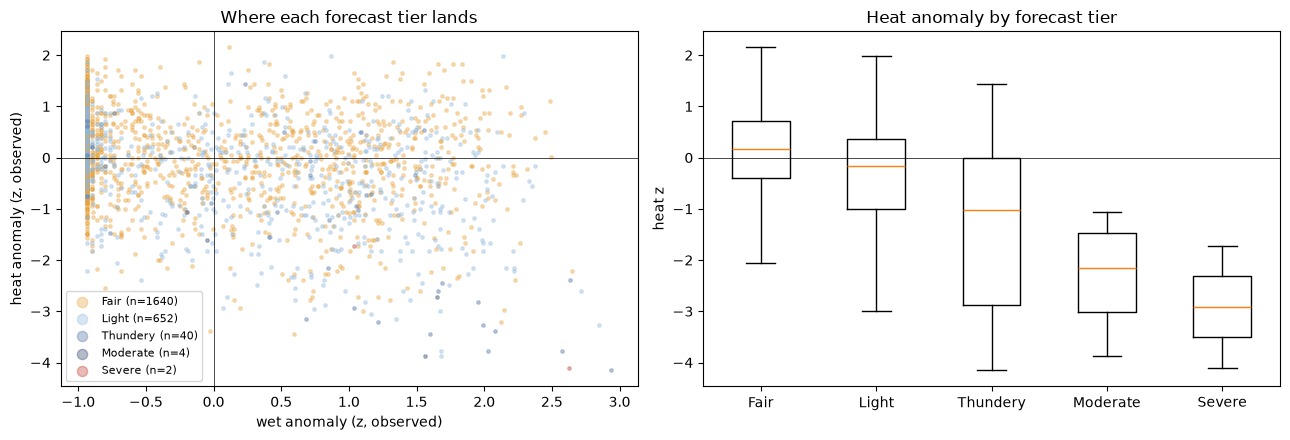

In [10]:
tr = daily.loc[train]
lr = np.log1p(daily.rain_mm)
daily["wet_z"] = (lr - np.log1p(tr.rain_mm).mean()) / np.log1p(tr.rain_mm).std()
daily["heat_z"] = (daily.tmax - tr.tmax.mean()) / tr.tmax.std()

pct = lambda q: (lambda s: s.quantile(q))
summ = (daily.dropna(subset=["fc_tier"]).groupby("fc_tier")[["heat_z", "wet_z", "tmax", "rain_mm"]]
        .agg(["count", "mean", "median", "std", pct(0.1), pct(0.9)]).reindex(TIERS))
summ.columns = [f"{a}_{b if isinstance(b, str) else ''}".replace("<lambda_0>", "p10").replace("<lambda_1>", "p90")
                for a, b in summ.columns]
display(summ.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
cm = dict(zip(TIERS, ["#e9a23b", "#8fb8de", "#4a6fa5", "#2a3d66", "#c0392b"]))
for t in TIERS:
    s = daily[daily.fc_tier == t]
    ax[0].scatter(s.wet_z, s.heat_z, s=6, alpha=0.35, color=cm[t], label=f"{t} (n={len(s)})")
ax[0].axhline(0, c="k", lw=.5); ax[0].axvline(0, c="k", lw=.5)
ax[0].set(xlabel="wet anomaly (z, observed)", ylabel="heat anomaly (z, observed)", title="Where each forecast tier lands")
ax[0].legend(markerscale=3, fontsize=8)
data = [daily.loc[daily.fc_tier == t, "heat_z"].dropna() for t in TIERS]
ax[1].boxplot([x if len(x) else [np.nan] for x in data], tick_labels=TIERS, showfliers=False)
ax[1].axhline(0, c="k", lw=.5); ax[1].set(title="Heat anomaly by forecast tier", ylabel="heat z")
plt.tight_layout(); plt.show()
if DEMO_MODE: print("DEMO — synthetic")

## §5 — Intervention bins

| Bin | Trigger (thresholds from train years only) | Owner action | Basis |
|---|---|---|---|
| `REACT` | Observed rain yesterday ≥ 50 mm | Post-event check; KH test if buffer low | Gauge — measured, not forecast (Ph. 3/4) |
| `PREEMPT` | Observed **hot today** AND outlook temp in train top 25% | Cut ration / raise aeration ahead of a hot stretch | Ph. 11: needs sensor **and** forecast |
| `WINDOW` | Pooled periods rank in train bottom 16% | Schedule water change / scrub / maintenance today | Ph. 8/9: dry-side asymmetry |
| `NONE` | Everything else (incl. all Thundery-only calls) | Silent. Chemistry is handled by gauge-driven dosing | Ph. 7/10: forecast adds nothing to KH/nitrate |

Priority: REACT > PREEMPT > WINDOW > NONE. Flags are kept separately because **WINDOW and PREEMPT co-occur**:
the best days to work on the pond are the worst days for the fish (Ph. 11).

In [11]:
OUT_HOT_THR = daily.loc[train, "outlook_temp_ahead"].quantile(OUTLOOK_HOT_Q)
WIN_THR = daily.loc[train, "pooled_rank"].quantile(WINDOW_Q)
DRY3_THR = daily.loc[train, "rain_next3"].quantile(0.30)

daily["f_react"]   = daily.rain_prev >= REACT_RAIN_MM
daily["f_preempt"] = (daily.hot == 1) & (daily.outlook_temp_ahead >= OUT_HOT_THR)
daily["f_window"]  = daily.pooled_rank <= WIN_THR
daily["label"] = np.select([daily.f_react, daily.f_preempt, daily.f_window], ["REACT", "PREEMPT", "WINDOW"], "NONE")
daily.loc[daily.pooled_rank.isna(), "label"] = np.nan

daily["y_preempt"] = daily.hot_next3                                   # hot day within t+1..t+3
daily["y_window"]  = np.where(daily.rain_mm.notna(), (daily.rain_mm < 1).astype(float), np.nan)
daily["y_window3"] = np.where(daily.rain_next3.notna(), (daily.rain_next3 <= DRY3_THR).astype(float), np.nan)

print(f"Thresholds — outlook hot ≥ {OUT_HOT_THR:.2f} °C | window rank ≤ {WIN_THR:.3f} | dry-3d ≤ {DRY3_THR:.1f} mm")
print("Label share:", (daily.label.value_counts(normalize=True) * 100).round(1).to_dict())
print(f"WINDOW ∧ PREEMPT same day: {(daily.f_window & daily.f_preempt).sum()} days")

def evaluate(mask, y, name):
    ok = y.notna() & mask.notna()
    m, yy = mask[ok].astype(bool), y[ok]
    n, k, base = int(m.sum()), int(yy[m].sum()), yy.mean()
    lo, hi = wilson(k, n)
    yrs = (y.index[ok].year.nunique()) or 1
    return dict(rule=name, fires_per_yr=n / yrs, pct_days=100 * m.mean(), n=n,
                precision=k / n if n else np.nan, ci_lo=lo, ci_hi=hi, base=base,
                lift=(k / n) / base if n and base else np.nan)

checks = [("PREEMPT: hot today ∧ hot outlook", "f_preempt", "y_preempt"),
          ("  baseline: hot today alone",      None,        "y_preempt"),
          ("  baseline: hot outlook alone",    "outlook_only", "y_preempt"),
          ("WINDOW → dry today (<1 mm)",       "f_window",  "y_window"),
          ("WINDOW → dry next 3 d",            "f_window",  "y_window3")]
daily["outlook_only"] = daily.outlook_temp_ahead >= OUT_HOT_THR
rows = []
for split, sel in [("train", train), ("TEST", test)]:
    d = daily[sel]
    for name, f, y in checks:
        mask = (d.hot == 1) if f is None else d[f]
        rows.append({"split": split, **evaluate(mask, d[y], name)})
res = pd.DataFrame(rows)
display(res.round(3))
print("A coin flip at the same firing rate has precision = base (lift 1.00).")
print(f"REACT fires {daily.f_react.sum()} days total ({daily.f_react.sum() / daily.year.nunique():.1f}/yr) — "
      "observational trigger, precision is 1 by construction.")

Thresholds — outlook hot ≥ 29.12 °C | window rank ≤ 0.100 | dry-3d ≤ 5.8 mm
Label share: {'NONE': 73.6, 'WINDOW': 13.5, 'PREEMPT': 10.5, 'REACT': 2.4}
WINDOW ∧ PREEMPT same day: 86 days


,split,rule,fires_per_yr,pct_days,n,precision,ci_lo,ci_hi,base,lift
0,train,PREEMPT: hot today ∧ hot outlook,44.6,12.549,223,0.897,0.850,0.930,0.564,1.589
1,train,baseline: hot today alone,111.8,31.458,559,0.782,0.746,0.814,0.564,1.385
2,train,baseline: hot outlook alone,99.4,27.968,497,0.781,0.742,0.815,0.564,1.383
3,train,WINDOW → dry today (<1 mm),55.0,16.215,275,0.858,0.812,0.894,0.488,1.760
4,train,WINDOW → dry next 3 d,53.4,16.152,267,0.551,0.491,0.609,0.300,1.835
5,TEST,PREEMPT: hot today ∧ hot outlook,14.0,4.803,28,0.643,0.458,0.793,0.218,2.951
6,TEST,baseline: hot today alone,29.5,10.120,59,0.644,0.517,0.754,0.218,2.957
7,TEST,baseline: hot outlook alone,102.0,34.991,204,0.289,0.231,0.355,0.218,1.328
8,TEST,WINDOW → dry today (<1 mm),60.5,20.370,121,0.860,0.786,0.910,0.524,1.642
9,TEST,WINDOW → dry next 3 d,58.0,19.761,116,0.560,0.470,0.647,0.341,1.645


A coin flip at the same firing rate has precision = base (lift 1.00).
REACT fires 57 days total (8.1/yr) — observational trigger, precision is 1 by construction.


In [12]:
per_year = []
for yr, d in daily.groupby("year"):
    for name, f, y in [("PREEMPT", "f_preempt", "y_preempt"), ("WINDOW", "f_window", "y_window")]:
        per_year.append({"year": yr, **evaluate(d[f], d[y], name)})
py = pd.DataFrame(per_year).pivot(index="year", columns="rule", values=["n", "precision", "base", "lift"]).round(3)
display(py)
for r in ["PREEMPT", "WINDOW"]:
    l = py[("lift", r)].dropna()
    print(f"{r}: lift > 1 in {(l > 1).sum()}/{len(l)} years; precision SD {py[('precision', r)].std():.3f}")

n        precision           base           lift       
rule PREEMPT WINDOW   PREEMPT WINDOW PREEMPT WINDOW PREEMPT WINDOW
year                                                              
2020    43.0   56.0     0.977  0.857   0.600  0.503   1.628  1.704
2021    22.0   65.0     0.864  0.908   0.562  0.507   1.536  1.790
2022    20.0   50.0     0.850  0.740   0.444  0.430   1.916  1.722
2023    54.0   53.0     0.889  0.887   0.585  0.506   1.518  1.753
2024    84.0   51.0     0.881  0.882   0.634  0.496   1.390  1.781
2025    19.0   62.0     0.737  0.839   0.268  0.482   2.746  1.740
2026     9.0   59.0     0.444  0.881   0.140  0.589   3.181  1.497

PREEMPT: lift > 1 in 7/7 years; precision SD 0.175
WINDOW: lift > 1 in 7/7 years; precision SD 0.056


## §6 — Simple ML: does the outlook add skill over the thermometer?
Logistic regression, time split (train ≤ `TRAIN_END`), **moving-block bootstrap** (7-day blocks) on the
test set for the AUC gain. Replicates the Phase 11 persistence-crossover test in a reproducible pipeline.
The rain target is included as a **control**: expect little gain there.

In [13]:
daily["m_sin"] = np.sin(2 * np.pi * daily.index.dayofyear / 365.25)
daily["m_cos"] = np.cos(2 * np.pi * daily.index.dayofyear / 365.25)

def block_boot_gain(y, pa, pb, B=1000, blk=7):
    y, pa, pb = map(np.asarray, (y, pa, pb)); n = len(y); nb = math.ceil(n / blk); g = []
    for _ in range(B):
        starts = RNG.integers(0, n - blk + 1, nb)
        idx = np.concatenate([np.arange(s, s + blk) for s in starts])[:n]
        if len(np.unique(y[idx])) < 2:
            continue
        g.append(roc_auc_score(y[idx], pb[idx]) - roc_auc_score(y[idx], pa[idx]))
    return np.percentile(g, [2.5, 97.5])

def compare(target, base_feats, full_feats, label):
    d = daily.assign(_y=target).dropna(subset=["_y", *full_feats])
    tr_, te_ = d.index <= TRAIN_END, d.index > TRAIN_END
    if te_.sum() < 50 or d.loc[tr_, "_y"].nunique() < 2 or d.loc[te_, "_y"].nunique() < 2:
        return dict(model=label, note="insufficient data")
    out = {}
    for tag, f in [("A", base_feats), ("B", full_feats)]:
        m = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)).fit(d.loc[tr_, f], d.loc[tr_, "_y"])
        out[tag] = m.predict_proba(d.loc[te_, f])[:, 1]
    yt = d.loc[te_, "_y"].values
    aA, aB = roc_auc_score(yt, out["A"]), roc_auc_score(yt, out["B"])
    lo, hi = block_boot_gain(yt, out["A"], out["B"])
    return dict(model=label, n_test=len(yt), base_rate=yt.mean(), auc_sensor=aA, auc_sensor_plus_nea=aB,
                gain=aB - aA, ci_lo=lo, ci_hi=hi, verdict="adds skill" if lo > 0 else ("hurts" if hi < 0 else "no clear gain"))

rows = []
for h in (1, 3, 5):
    L = min(h, 4)
    rows.append(compare(daily.hot.shift(-h), ["tmax", "tmax_3d", "m_sin", "m_cos"],
                        ["tmax", "tmax_3d", "m_sin", "m_cos", f"out_t{L}", f"out_rank{L}", "pooled_rank"],
                        f"hot day at +{h}d"))
rows.append(compare((daily.rain_mm.shift(-1) >= 10).astype(float).where(daily.rain_mm.shift(-1).notna()),
                    ["rain_mm", "rain_7d", "m_sin", "m_cos"],
                    ["rain_mm", "rain_7d", "m_sin", "m_cos", "pooled_rank", "out_rank1"],
                    "CONTROL: ≥10 mm rain at +1d"))
ml = pd.DataFrame(rows)
display(ml.round(3))
print("A = observed sensors + seasonality only. B = A + NEA periods/outlook. "
      "Gain CI from 7-day moving-block bootstrap on test years.")

,model,n_test,base_rate,auc_sensor,auc_sensor_plus_nea,gain,ci_lo,ci_hi,verdict
0,hot day at +1d,584,0.104,0.810,0.778,-0.032,-0.075,0.016,no clear gain
1,hot day at +3d,578,0.102,0.760,0.723,-0.037,-0.088,0.016,no clear gain
2,hot day at +5d,577,0.101,0.718,0.713,-0.005,-0.047,0.043,no clear gain
3,CONTROL: ≥10 mm rain at +1d,591,0.225,0.555,0.613,0.058,0.022,0.095,adds skill


A = observed sensors + seasonality only. B = A + NEA periods/outlook. Gain CI from 7-day moving-block bootstrap on test years.


**Reading §6.** Phase 11 found the outlook *hurts* at +1 d, helps at +3/+5 d. If this pipeline reproduces
that on observed Tmax, the heat claim survives an independent, reproducible re-test. If the rain control
shows a gain that does **not** convert into better control outcomes — that is the Phase 7/10 result:
more prediction skill on a variable that is not control-loop-scarce.

## §7 — Export

In [14]:
OUT_DIR.mkdir(exist_ok=True, parents=True)
tag = "DEMO_" if DEMO_MODE else ""
view.sort_values("test_lift", ascending=False).to_csv(OUT_DIR / f"{tag}apriori_rules.csv", index=False)
daily[["pooled_rank", "fc_tier", "rain_mm", "tmax", "outlook_temp_ahead",
       "f_react", "f_preempt", "f_window", "label"]].to_csv(OUT_DIR / f"{tag}daily_labels.csv")
res.to_csv(OUT_DIR / f"{tag}intervention_validation.csv", index=False)
ml.to_csv(OUT_DIR / f"{tag}ml_skill.csv", index=False)
impact.to_csv(OUT_DIR / f"{tag}damage_table.csv")
print("Wrote:", sorted(p.name for p in OUT_DIR.glob(f"{tag}*.csv")))

Wrote: ['apriori_rules.csv', 'daily_labels.csv', 'damage_table.csv', 'intervention_validation.csv', 'ml_skill.csv']


## Caveats to carry into the write-up
- **Water temperature ≠ air temperature.** Everything heat-related here uses observed *air* Tmax. The air→water
  offset/lag must be fitted against the pond's own sensor before quoting any "hot days per year".
- **Depth dependence.** §3 assumes a 1.2 m column. At 400 mm, 100 mm of rain removes ~22% of KH, not 8% —
  the chemistry null can invert for shallow ponds.
- **Apriori multiple comparisons.** Hundreds of candidate rules are tested; only report rules that hold out on
  test years, and treat anything with `test_n` < ~100 as a hypothesis.
- **Moderate/Severe are rare** (n ≈ 18–37 historically) and non-monotonic — don't build on either alone.
- **Runoff/contaminant washing** (intensity × catchment) is the most plausible real rain mechanism and is not
  modelled anywhere in this notebook.